In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/cookie_cats_cleaned.csv')
df.head()

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True


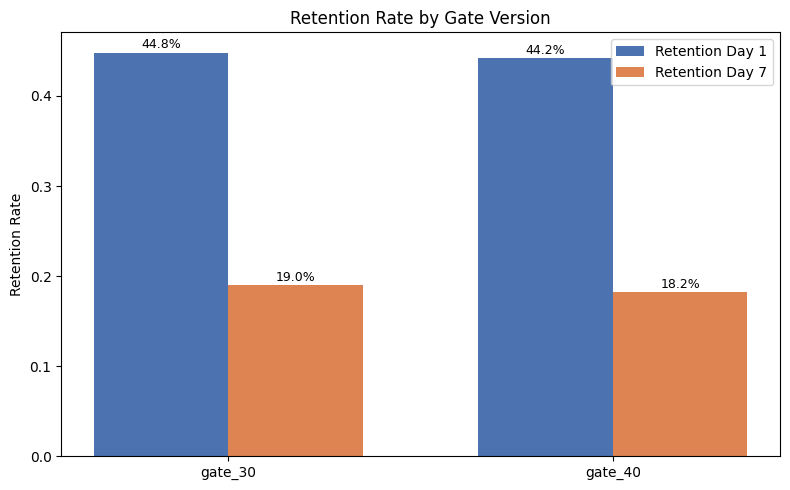

In [4]:
groups = ['gate_30', 'gate_40']
retention_1_rates = [0.4482, 0.4423]
retention_7_rates = [0.1902, 0.1820]

x = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, retention_1_rates, width, label='Retention Day 1', color='#4C72B0')
bars2 = ax.bar(x + width/2, retention_7_rates, width, label='Retention Day 7', color='#DD8452')

ax.set_ylabel('Retention Rate')
ax.set_title('Retention Rate by Gate Version')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.1%}', xy=(bar.get_x() + bar.get_width()/2, height),
                    xytext=(0, 3), textcoords="offset points", ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/retention_by_group.png', dpi=150)

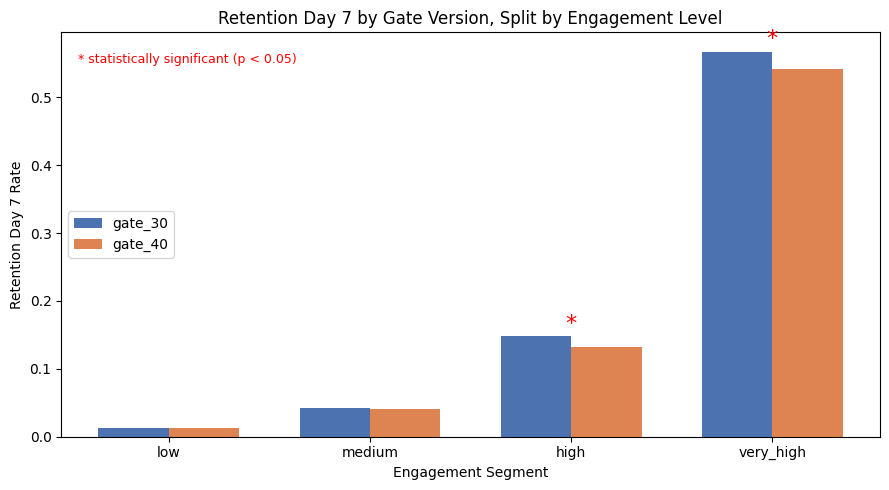

In [5]:
segments = ['low', 'medium', 'high', 'very_high']
gate_30_rates = [0.01219, 0.04173, 0.14773, 0.56747]
gate_40_rates = [0.01311, 0.04094, 0.13219, 0.54249]

x = np.arange(len(segments))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, gate_30_rates, width, label='gate_30', color='#4C72B0')
bars2 = ax.bar(x + width/2, gate_40_rates, width, label='gate_40', color='#DD8452')

ax.set_ylabel('Retention Day 7 Rate')
ax.set_xlabel('Engagement Segment')
ax.set_title('Retention Day 7 by Gate Version, Split by Engagement Level')
ax.set_xticks(x)
ax.set_xticklabels(segments)
ax.legend()

# Mark which segments were statistically significant
p_values = [0.518, 0.777, 0.00077, 0.00017]
for i, p in enumerate(p_values):
    if p < 0.05:
        ax.annotate('*', xy=(i, max(gate_30_rates[i], gate_40_rates[i]) + 0.01),
                    ha='center', fontsize=16, color='red')

ax.text(0.02, 0.95, '* statistically significant (p < 0.05)', transform=ax.transAxes,
        fontsize=9, color='red', va='top')

plt.tight_layout()
plt.savefig('../visuals/segment_analysis.png', dpi=150)
plt.show()

In [6]:
##Copied from hypothesis_testing.ipynb
def bootstrap_diff(df, group_col, metric_col, group_a, group_b, n_iterations=10000):
    a = df[df[group_col] == group_a][metric_col].values
    b = df[df[group_col] == group_b][metric_col].values
    
    diffs = []
    for _ in range(n_iterations):
        sample_a = np.random.choice(a, size=len(a), replace=True)
        sample_b = np.random.choice(b, size=len(b), replace=True)
        diffs.append(sample_b.mean() - sample_a.mean())
    
    diffs = np.array(diffs)
    ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])
    return diffs, ci_low, ci_high

boot_diffs_ret1, boot_ci_low1, boot_ci_high1 = bootstrap_diff(
    df, 'version', 'retention_1', 'gate_30', 'gate_40'
)
print(f"Bootstrap 95% CI (retention_1 diff): [{boot_ci_low1:.4f}, {boot_ci_high1:.4f}]")

boot_diffs_ret7, boot_ci_low7, boot_ci_high7 = bootstrap_diff(
    df, 'version', 'retention_7', 'gate_30', 'gate_40'
)
print(f"Bootstrap 95% CI (retention_7 diff): [{boot_ci_low7:.4f}, {boot_ci_high7:.4f}]")

Bootstrap 95% CI (retention_1 diff): [-0.0124, 0.0006]
Bootstrap 95% CI (retention_7 diff): [-0.0132, -0.0029]


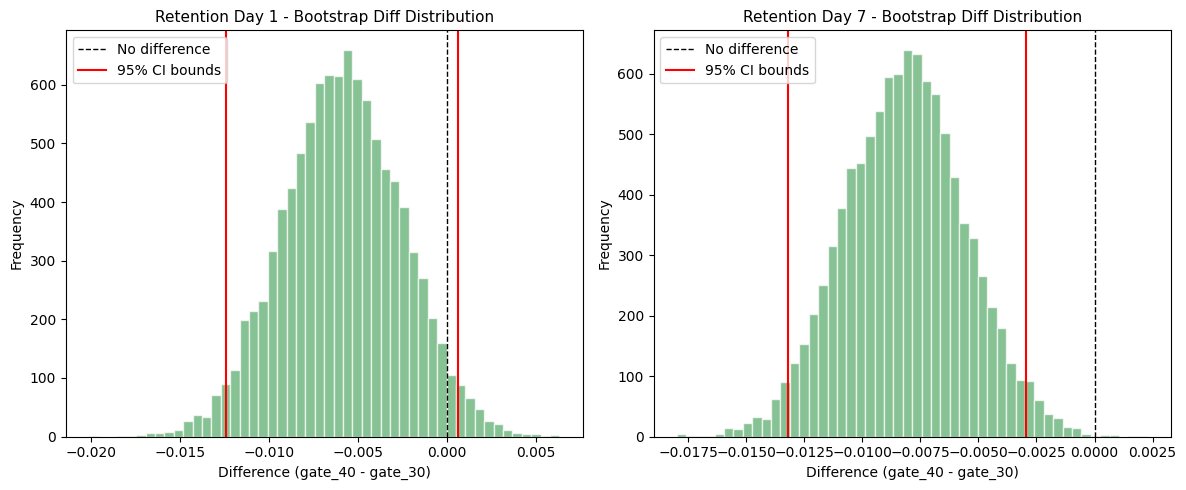

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, diffs, ci_low, ci_high, title in zip(
    axes,
    [boot_diffs_ret1, boot_diffs_ret7],
    [boot_ci_low1, boot_ci_low7],
    [boot_ci_high1, boot_ci_high7],
    ['Retention Day 1 - Bootstrap Diff Distribution', 'Retention Day 7 - Bootstrap Diff Distribution']
):
    ax.hist(diffs, bins=50, color='#55A868', alpha=0.7, edgecolor='white')
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='No difference')
    ax.axvline(ci_low, color='red', linestyle='-', linewidth=1.5, label='95% CI bounds')
    ax.axvline(ci_high, color='red', linestyle='-', linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Difference (gate_40 - gate_30)')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.savefig('../visuals/bootstrap_distributions.png', dpi=150)
plt.show()

In [10]:



# 2. Summary table: overall retention rates by group
summary_df = pd.DataFrame({
    'metric': ['retention_1', 'retention_1', 'retention_7', 'retention_7'],
    'version': ['gate_30', 'gate_40', 'gate_30', 'gate_40'],
    'rate': [0.4482, 0.4423, 0.1902, 0.1820]
})
summary_df.to_csv('../data/retention_summary.csv', index=False)

# 3. Segment-level summary (your key finding)
segment_df = pd.DataFrame({
    'segment': ['low', 'low', 'medium', 'medium', 'high', 'high', 'very_high', 'very_high'],
    'version': ['gate_30', 'gate_40'] * 4,
    'retention_7_rate': [0.01219, 0.01311, 0.04173, 0.04094, 0.14773, 0.13219, 0.56747, 0.54249],
    'p_value': [0.518, 0.518, 0.777, 0.777, 0.00077, 0.00077, 0.00017, 0.00017],
    'significant': [False, False, False, False, True, True, True, True]
})
segment_df.to_csv('../data/segment_summary.csv', index=False)
